### 1、基于RODM模型开展风浪耦合模型研究。考虑波浪谱和API风谱
### 2、该模型是风浪耦合工作1的进一步拓展工作。

In [6]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP

### 经典水弹性计算波浪问题

In [7]:
# setting initial parameter, reading mass and stiffness matrix
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
master_nodes_length = len(master_nodes)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\BM10_direaction0_full.nc"))
omega = dataset.omega.values
omega_number = np.arange(0,40,1)

In [8]:
Area = 5*5
nodes_per_row = 61
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
# node displacement
displacement = []
F_wave = []
mass_full = []
damping_full = []
stiffness_full = []
for i in omega_number:
    # print("计算进展：",i/39)
    # read hydrodynamic data
    added_mass = dataset['added_mass'][i].values
    radiation_damping = dataset['radiation_damping'][i].values
    inertia_matrix = dataset['inertia_matrix'].values
    # hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values
    # REDUCE THE MATRICES
    added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
    # hyrostatic stiffness or fem spring stiffness
    # 1. choice hydrostatic stiffness
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,master_nodes_length,[5])

    inertia_matrix = SEREP.reduce_dofs(inertia_matrix,master_nodes_length,[5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, master_nodes_length, 5).reshape(1,5*master_nodes_length)
    # F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
    # Generate the system matrices
    mass = added_mass + MR
    damping = radiation_damping
    stiffness =  hydrostatic_stiffness + KR
    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega[i])
    # Restore global displacement under disorder masterdofs and slavedofs
    global_displacement_disorder = T @ master_displacement
    # Reorder global displacement under order
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
    # 保存数据
    mid = global_displacement[2::5,:]
    displacement.append(mid)
    F_wave.append(F_w)
    mass_full.append(mass)
    damping_full.append(damping)
    stiffness_full.append(stiffness)
    

In [4]:
displacement = np.array(displacement).reshape(40,793)
average_heave_displacement = np.mean(abs(displacement), axis=1)

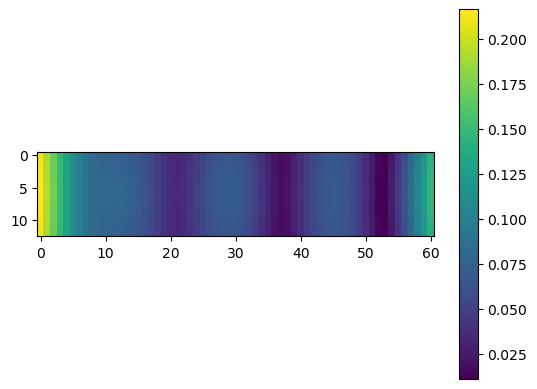

In [5]:
displacement = np.array(displacement).reshape(40,13,61)
plt.imshow(abs(displacement[25,:,:]))
plt.colorbar()

In [19]:
np.diag(KR)[5::5]

array([3.62460245e+35, 1.03205124e+35, 4.02933424e+35, 5.38162673e+34,
       4.48358902e+35, 1.69671626e+35, 4.58684473e+35, 5.09697845e+33,
       1.61496876e+35])

In [26]:
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Hinge\Job_hinge_study_150_60_STIF1.mtx' 

k_1 = dm_r.get_stiffness_matrix(file_k)
k_2 = dm_r.get_stiffness_matrix(file_k)

In [32]:
# 使用 np.block 创建块对角矩阵
big_matrix = np.block([
    [k_1, np.zeros((k_1.shape[0], k_2.shape[1]))],
    [np.zeros((k_2.shape[0], k_1.shape[1])), k_2]
])

print("大矩阵的维度:", big_matrix.shape)

大矩阵的维度: (4836, 4836)


In [34]:
def calculate_column_node_indices(column_number, nodes_per_row, rows_per_column):
    """
    计算给定列的节点编号。

    :param column_number: int，指定要计算的列号（从1开始计数）
    :param nodes_per_row: int，每行的节点数
    :param rows_per_column: int，每列的节点数
    :return: list，该列的所有节点编号
    """
    # 验证输入
    if column_number < 1 or column_number > nodes_per_row:
        raise ValueError("列号超出范围")
    
    # 计算该列的所有节点编号
    column_indices = [(row_index - 1) * nodes_per_row + column_number
                      for row_index in range(1, rows_per_column + 1)]
    return column_indices

# 使用示例
nodes_per_row = 31
rows_per_column = 13
column_number = 31  # 例如，计算第一列的节点编号
column_node_indices = calculate_column_node_indices(column_number, nodes_per_row, rows_per_column)
print("节点编号：", column_node_indices)


节点编号： [31, 62, 93, 124, 155, 186, 217, 248, 279, 310, 341, 372, 403]


In [37]:
# 假设 KC 是一个 6x6 矩阵，描述了两个节点间自由度的连接方式
k_hinge = 1e15
KC = np.diag([k_hinge,k_hinge,k_hinge,k_hinge,0,k_hinge])  # 你需要提供这个矩阵的具体值
negative_KC = -KC
# K_1 的节点编号
nodes_k1 = [31, 62, 93, 124, 155, 186, 217, 248, 279, 310, 341, 372, 403]
# K_2 的节点编号
nodes_k2 = [1, 32, 63, 94, 125, 156, 187, 218, 249, 280, 311, 342, 373]

for node1, node2 in zip(nodes_k1, nodes_k2):
    # 计算在大矩阵中的索引位置
    index1 = (node1 - 1) * 6  # K_1 节点自由度起始位置
    index2 = (node2 - 1 + 403) * 6  # K_2 节点自由度起始位置

    # 在节点自身设置 KC
    big_matrix[index1:index1+6, index1:index1+6] += KC
    big_matrix[index2:index2+6, index2:index2+6] += KC

    # 设置两节点间的相互作用 -KC
    big_matrix[index1:index1+6, index2:index2+6] += negative_KC
    big_matrix[index2:index2+6, index1:index1+6] += negative_KC

In [38]:
big_matrix[]

4836

In [48]:
master_nodes = DM_A.calculate_node_positions(403,6,5)

In [51]:
num_nodes = 403
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

In [52]:
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Hinge\Job_hinge_study_150_60_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Hinge\Job_hinge_study_150_60_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs 
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs


# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)

In [54]:
KR_1 = KR
KR_2 = KR


(25, 25)

In [40]:
4836-4758

78

In [41]:
78/6

13.0

In [23]:
# 找出x=150位置的所有节点编号
hinged_nodes = [i for i, (x, y, z) in enumerate(nodes) if x == 150]

NameError: name 'nodes' is not defined

### 上述为计算RAO，下面为引入波浪载荷谱

In [ ]:
# define jonswap wave spectrum
def jonswap(Hs, Tp, gamma, omega):
    '''
        Hs: significant wave height
        Tp: peak period
        gamma: peak enhancement factor
        omega: 角频率
        jonswap wave spectrum, refrerence:
        https://www.sciencedirect.com/science/article/pii/S0960148116301446
        omega=2*pi*f, f为频率, omega为角频率,最终结果需要乘以2*pi
        以与论文结果对比验证
    '''
    fp = 2*np.pi/Tp
    # if omega.all() < fp:
    #     sigma = 0.07
    # else:
    #     sigma = 0.09
    sigma = np.where(omega <= fp, 0.07, 0.09)
    alpha = 0.0624 / (0.230 + 0.0336 * gamma - (0.185 / (1.9+gamma)))
    beta = np.exp(-(omega-fp)**2/(2*(sigma**2)*(fp**2)))
    return alpha*Hs**2*fp**4*omega**(-5)*gamma**beta*np.exp(-1.25*(fp/omega)**4)*2*np.pi # 乘以2*pi是为了与论文结果对比验证

# wave spectrum
Hs = 3.25
Tp = 8.29
gamma = 3.3
omega = np.linspace(0.1, 2, 40)
S = jonswap(Hs, Tp, gamma, omega)
plt.plot(omega, S)

In [ ]:
plt.plot((2*np.pi)/omega,average_heave_displacement)

In [ ]:
# 计算响应谱
response_spectrum = average_heave_displacement ** 2 * S
plt.plot(omega, response_spectrum)

### 单独风载荷计算

In [2]:
# setting initial parameter, reading mass and stiffness matrix
num_nodes = 4681 # 4681
master_nodes = DM_A.calculate_node_positions(2409,15,10) #DM_A.calculate_node_positions(424,6,10)
master_nodes_length = len(master_nodes)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\BM10_direaction0_wind_model.nc"))
omega = dataset.omega.values
omega_number = np.arange(0,40,1)
# 读取质量和刚度矩阵
Area = 5*5
nodes_per_row = 61
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh-22_wind_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh-22_wind_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)
# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])
# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)
# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)

In [15]:
import numpy as np
from scipy.io import savemat
# 由于求解特征函数时间较长，故采取保存方式，该矩阵求解时间超过了八分钟
save_path = 'reduced_matrices_wind.mat'

# Create a dictionary of the matrices you want to save
matrices = {
    'MR': MR, # Reduced mass matrix
    'KR': KR, # Reduced stiffness matrix
    'T': T    # Transformation matrix
}

# Save the matrices to a .mat file
savemat(save_path, matrices)

print(f'Matrices saved to {save_path}')

Matrices saved to reduced_matrices_wind.mat


In [16]:
# 读取由于求解特征函数时间较长，故采取保存方式的矩阵
from scipy.io import loadmat

# 定义保存矩阵的文件路径
file_path = 'reduced_matrices_wind.mat'

# 读取.mat文件
loaded_matrices = loadmat(file_path)

# 从加载的数据中提取矩阵
MR = loaded_matrices['MR']  # 读取缩减的质量矩阵
KR = loaded_matrices['KR']  # 读取缩减的刚度矩阵
T = loaded_matrices['T']    # 读取变换矩阵

In [17]:
# 引入风载荷计算类
import DM_Windload as DM_Wind
windload_cd = DM_Wind.WindLoad(U10=45, z=3, total_rows=31, total_cols=151, file_path="E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cd_degree0.txt")
windload_cl = DM_Wind.WindLoad(U10=45, z=3, total_rows=31, total_cols=151, file_path="E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cl_degree0.txt")
# 定义风产生的阻尼效应
Wind_Damping = windload_cd.compute_wind_damping(dof=0) + windload_cl.compute_wind_damping(dof=2) + windload_cd.compute_wind_damping(dof=4)*1


In [18]:
# 脉动风载荷的计算流程
# 在对象中读取风载荷系数矩阵
cd = windload_cd.wind_load_coefficient()
cl = windload_cl.wind_load_coefficient()

# 函数定义，将系数矩阵分解为 10 个子模块
def compute_submodule_wind_load_coefficients(cc):
    """
    计算子模块风载荷系数

    参数：
    cc: numpy.ndarray，大小为 (31, 151) 的载荷矩阵

    返回值：
    submatrices: list，包含 10 个子模块的载荷系数矩阵
    """
    # 对特定列进行除以 2 的操作
    cc[:, 15::15] /= 2
    
    # 提取要插入的列数据
    boundary_columns = cc[:, 15::15]
    # 删除最后一列
    boundary_columns = boundary_columns[:, :-1]
    # print(boundary_columns.shape)
    # 初始化新矩阵，复制原始矩阵 cc
    cc_new = cc.copy()
    
    # 在每个间隔为 15 的位置插入相应的列
    for i in range(boundary_columns.shape[1]):
        insert_position = 15 + 15 * i + i  # 计算插入位置
        cc_new = np.insert(cc_new, insert_position, boundary_columns[:, i], axis=1)
    
    # 将新矩阵分解为 10 个子模块
    submatrices = np.array_split(cc_new, 10, axis=1)
    
    return submatrices

#分隔为10个模块
cd_submodules = compute_submodule_wind_load_coefficients(cd)
cl_submodules = compute_submodule_wind_load_coefficients(cl)

# 计算子模块风载荷系数
cd_sums = np.array([np.sum(matrix) for matrix in cd_submodules])
cl_sums = np.array([np.sum(matrix) for matrix in cl_submodules])

#计算风谱下风速脉动幅值
target_frequency = 0.1
amplitude = windload_cd.compute_amplitude_for_frequency(target_frequency)
#计算多节点之间的相位关系
def calculate_phases(num_points, wind_speed, angular_frequency, distance):
    """
    计算相位关系
    
    参数：
    num_points: int, 节点数量
    wind_speed: float, 平均风速
    angular_frequency: float, 角频率
    distance: float, 两点之间的距离
    
    返回值：
    phases: list, 包含每个节点相位的列表
    """
    delta_theta = angular_frequency * distance / wind_speed
    phases = [i * delta_theta for i in range(num_points)]
    return phases

wind_speed = 45
distance = 30
phases = calculate_phases(10, wind_speed, target_frequency, distance)
#得到风速的复数形式
amplitude_complex = amplitude * (np.cos(phases) + 1j * np.sin(phases))

#计算风载荷
V_avg = windload_cd.adjust_wind_speed() # 考虑地形后的平均风速
A = 1 # 投影面积
rho = 1.225 #空气密度
# x 方向风载荷
wind_force_x = 2 * cd_sums * V_avg * amplitude_complex * A * rho
# z 方向风载荷
wind_force_z = 2 * cl_sums * V_avg * amplitude_complex * A * rho
# my 方向风载荷
wind_force_my = 2 * cd_sums * V_avg * amplitude_complex * A * rho * 1
# 由于载荷的转移而引起的弯矩
a1 = cl_submodules[0] # 模块1风载荷系数
b1 = np.zeros((31, 16)) # 接受矩阵
for i in range(8):
    b1[:,i] = a1[:,i] - a1[:,15-i]

def euclidean_distance(x1, y1, x2, y2):
    """
    计算两个点之间的欧几里得距离
    
    parameters:
    输入两个点的坐标

    return:
    两个点之间的欧几里得距离
    """
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def distance_matrix(center_x, center_y, grid_width, grid_height):
    """
    计算节点之间的距离矩阵
    
    input parameters:
    1、目标点坐标
    2、节点数量,行和列,这里单元大小被设置为2
    """
    # 计算中心点的坐标
    center_point = (center_x, center_y)
    # 创建一个空的距离矩阵
    distances = np.zeros((grid_height, grid_width))
    # 计算每个节点到中心点的距离并填充到距离矩阵中
    for i in range(grid_width):
        for j in range(grid_height):
            node_x = i * 2  # 节点的 x 坐标
            node_y = j * 2  # 节点的 y 坐标
            distances[j][i] = euclidean_distance(center_x, center_y, node_x, node_y)
    return distances

# # 示例调用，调用计算距离问题
# center_x = 15
# center_y = 30
# # 节点数量，行和列
# grid_width = 16
# grid_height = 31
# # 计算距离矩阵
# dist_matrix = distance_matrix(center_x, center_y, grid_width, grid_height)
# 鉴于目标点到重心位置可能存在夹角，从而引起mx方向的弯矩，在Mx的计算中实际应该抵消，但是这个无单位，处理
# 起来相对复杂，故采用均匀力的方式进行。
dist_matrix = 7.5 
# 计算弯矩
transfor_force_my = 2 * V_avg * np.sum(b1) * dist_matrix * amplitude_complex[0] * A * rho
# 将弯矩加入第一个模块的载荷中
wind_force_my[0] += transfor_force_my
# 形成脉动风载荷矩阵
wind_load = np.zeros(50,dtype=complex)
wind_load[0:60:5] = wind_force_x
wind_load[2:60:5] = wind_force_z
wind_load[4:60:5] = wind_force_my

In [19]:
# 计算运动方程，包括附加质量、附加阻尼、刚度、风荷载。
num_nodes = 4681 # 4681
master_nodes = DM_A.calculate_node_positions(2409,15,10) #DM_A.calculate_node_positions(424,6,10)
master_nodes_length = len(master_nodes)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\BM10_direaction0_wind_model.nc"))
omega = dataset.omega.values
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)


In [20]:
# 计算运动方程，包括附加质量、附加阻尼、刚度、风荷载。
num_nodes = 4681 # 4681
master_nodes = DM_A.calculate_node_positions(2409,15,10) #DM_A.calculate_node_positions(424,6,10)
master_nodes_length = len(master_nodes)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\BM10_direaction0_wind_model.nc"))
omega = dataset.omega.values
omega_number = np.arange(0,1,1)
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)
wind_displacement = []
for i in omega_number:
    # print("计算进展：",i/39)
    # read hydrodynamic data
    added_mass = dataset['added_mass'][i].values
    radiation_damping = dataset['radiation_damping'][i].values
    # Wind_Force = windload_cd.compute_wind_force(omega[i], dof=0) + windload_cl.compute_wind_force(omega[i], dof=2) + windload_cd.compute_wind_force(omega[i], dof=4)*1
    # wind_force = SEREP.reduce_force_matrix_dofs(Wind_Force, num_nodes, 5).reshape(5*num_nodes)
    wind_damping = SEREP.reduce_dofs(Wind_Damping,num_nodes,[5])
    # REDUCE THE MATRICES
    added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
    # hyrostatic stiffness or fem spring stiffness
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,master_nodes_length,[5])

    mass = added_mass + MR
    damping = radiation_damping + T.T@wind_damping@T
    stiffness =  hydrostatic_stiffness + KR
    # wind_force = (T.T@wind_force).reshape(1,5*master_nodes_length)
    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, wind_load.reshape(1,50), omega[i])
    # Restore global displacement under disorder masterdofs and slavedofs
    global_displacement_disorder = T @ master_displacement
    # Reorder global displacement under order
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
    # print(global_displacement.shape)
    # 保存数据
    # mid = global_displacement[2::5,:] #
    # wind_displacement.append(mid)


In [27]:
wind_load.max()

(15775.61029052725+0j)

In [30]:
hydrostatic_stiffness.max()

5291160840.0

In [21]:
global_displacement.shape

(23405, 1)

In [22]:
heave = global_displacement[2::5,:]

In [23]:
heave = heave.reshape(31,151)

In [24]:
displacement_1 = heave[0,:]
displacement_mid = heave[15,:]
displacement_end = heave[30,:]

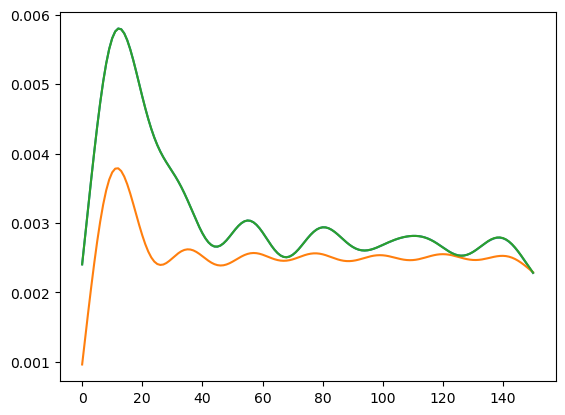

In [25]:
plt.plot(abs(displacement_1))
plt.plot(abs(displacement_mid))
plt.plot(abs(displacement_end))

In [9]:
wind_displacement_2d = np.array(wind_displacement).reshape(40,31,151)

In [10]:
displacement = np.array(wind_displacement).reshape(40,num_nodes)
displacement_1 = displacement[:,0]
displacement_mid = displacement[:,75]
displacement_end = displacement[:,150]
average_heave_displacement = np.mean(abs(displacement), axis=1)

In [11]:
displacement_2d = abs(displacement.reshape(40,31,151))

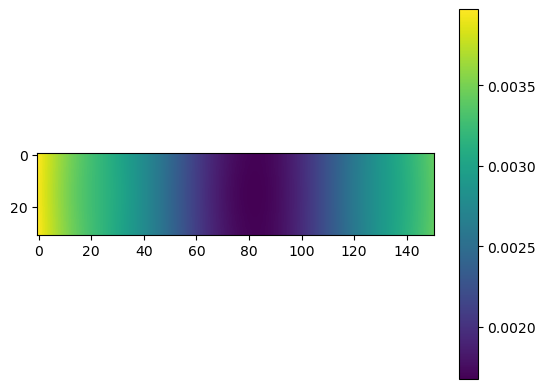

In [12]:
plt.imshow(abs(wind_displacement_2d[15,:,:]))
plt.colorbar()

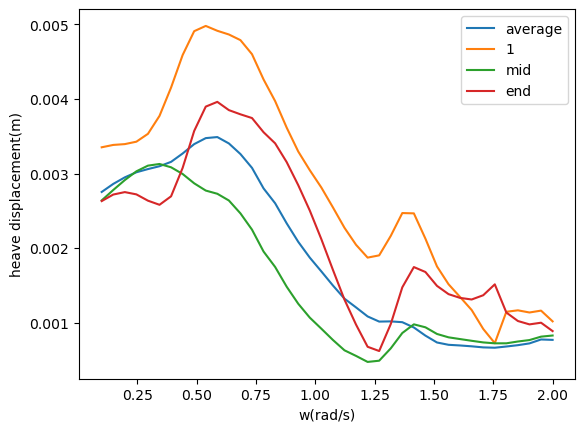

In [13]:
plt.plot(omega,abs(average_heave_displacement))
plt.plot(omega,abs(displacement_1))
plt.plot(omega,abs(displacement_mid))
plt.plot(omega,abs(displacement_end))
plt.xlabel('w(rad/s)')
plt.ylabel('heave displacement(m)')
plt.legend(['average','1','mid','end'])

In [ ]:
plt.plot((2*np.pi)/omega,abs(average_heave_displacement))
plt.plot((2*np.pi)/omega,abs(displacement_1))
plt.plot((2*np.pi)/omega,abs(displacement_mid))
plt.plot((2*np.pi)/omega,abs(displacement_end))
plt.xlabel('T(s)')
plt.ylabel('heave displacement(m)')
plt.legend(['average','1','mid','end'])

In [ ]:
S_wind = average_heave_displacement**2*windload_cd.api_spectrum()

In [ ]:
plt.plot(omega,S_wind)

### 使用原方法计算风载荷，验证结果是否正确。

In [ ]:
# 原方法

"""
Calculate the displacement for a given system of order method.

Parameters:
N (int): The number of nodes in the system.
file_path (str): Path to the stiffness matrix file.
dataset (DataFrame): A pandas DataFrame containing the necessary data.
nodes (array): Array of node positions.

Returns:
ndarray: The displacement array.
"""
N = 4681 # 4681
nodes = DM_A.calculate_node_positions(2409,15,10)
file_path = "E:\phd\Code\DM-FEM2D\StructureData\JobMesh-22_STIF1.mtx"

file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh-22_MASS1.mtx'

Mass_fem = dm_r.get_stiffness_matrix(file_m)


dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\BM10_direaction0_full.nc"))
omega = dataset.omega.values
i  = 30
# Extract data from the dataset
added_mass = dataset['added_mass'][i].values
radiation_damping = dataset['radiation_damping'][i].values
inertia_matrix = dataset['inertia_matrix'].values
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
# F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values


import DM_Windload as DM_Wind
windload_cd = DM_Wind.WindLoad(U10=45, z=3, total_rows=31, total_cols=151, file_path="E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cd_degree0.txt")
windload_cl = DM_Wind.WindLoad(U10=45, z=3, total_rows=31, total_cols=151, file_path="E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cl_degree0.txt")

Wind_Damping = windload_cd.compute_wind_damping(dof=0) + windload_cl.compute_wind_damping(dof=2) + windload_cd.compute_wind_damping(dof=4)*1
Wind_Force = windload_cd.compute_wind_force(omega[i], dof=0) + windload_cl.compute_wind_force(omega[i], dof=2) + windload_cd.compute_wind_force(omega[i], dof=4)*1
# Construct the combined matrices
M = added_mass  # Total mass
C = radiation_damping  # Damping
K = hydrostatic_stiffness  # Stiffness

from scipy.sparse import csr_matrix
# Insert matrices into the system
mass = csr_matrix(DM_A.insert_matrix(N, M, nodes) + Mass_fem)
damping = csr_matrix(DM_A.insert_matrix(N, C, nodes))
hy_stiffness = DM_A.insert_matrix(N, K, nodes)

# Assemble the stiffness matrix
stiffness = csr_matrix(dm_r.get_stiffness_matrix(file_path)*0.01 + hy_stiffness)

# Solve in the frequency domain
X = DM_A.sparse_solve_frequency_domain(mass, damping+Wind_Damping, stiffness, Wind_Force, omega[i])


In [ ]:
# 静力学测试
import DM_Windload as DM_Wind
windload_cd = DM_Wind.WindLoad(U10=45, z=3, total_rows=31, total_cols=151, file_path="E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cd_degree0.txt")
windload_cl = DM_Wind.WindLoad(U10=45, z=3, total_rows=31, total_cols=151, file_path="E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cl_degree0.txt")

Wind_Force = windload_cd.compute_wind_force(omega[i], dof=0) + windload_cl.compute_wind_force(omega[i], dof=2) + windload_cd.compute_wind_force(omega[i], dof=4)*1

# file_path = "E:\phd\Code\DM-FEM2D\StructureData\JobMesh-22_STIF1.mtx"

# kk = dm_r.get_stiffness_matrix(file_path)

# X = np.linalg.solve(kk, Wind_Force.T)


In [ ]:
plt.imshow(abs(Wind_Force[0,4::6].reshape(31,151)))
plt.colorbar()

In [ ]:
# 计算全载荷
# F_wind_drag = windload_cd.compute_wind_force_for_all_range(dof=0)
# F_wind_lift = windload_cl.compute_wind_force_for_all_range(dof=2)

In [ ]:
target_frequncy = 0.1
F_wind_drag = windload_cd.compute_wind_force(target_frequncy,dof=0)
F_wind_lift = windload_cl.compute_wind_force(target_frequncy,dof=2)
F_damping_drag = windload_cd.compute_wind_damping(dof=0)
F_damping_lift = windload_cd.compute_wind_damping(dof=2)
F_wind = F_wind_drag + F_wind_lift
F_damping = F_damping_drag + F_damping_lift

In [ ]:
F_wind[:,0:6]

In [ ]:
F_damping[:,0:6]

In [ ]:
# 绘制内力图
from DM_Verify import process_exp_data
exp_x, exp_y = process_exp_data(r"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\fig9_bm_fu.txt")
exp_y = np.array(exp_y)
data = analyzer.get_middle_interface_forces(global_forces)
x = np.arange(len(data))
y = data[:, 0]
from scipy import interpolate
spline = interpolate.CubicSpline(x, y)
x_new = np.linspace(0, len(data)-1, 300)
y_new = spline(x_new)
plt.plot(exp_x,exp_y/60,color = 'red', label = 'Fu et al.')
plt.scatter(x/10, y/1e6, color='black', s=10,label='Interface')
plt.plot(x_new/10, y_new/1e6,color ='black', label='Present')
plt.legend()
# plt.title("Scatter Plot and Cubic Spline Interpolation")
plt.xlabel(r"$x$/$L$")
plt.ylabel(r"$M_y$($MN{\cdot}m$)")
plt.ylim(0,3)

In [ ]:
# 绘制内力图
from DM_Verify import process_exp_data
exp_x, exp_y = process_exp_data(r"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\fig9_bm_fu.txt")
exp_y = np.array(exp_y)
data = analyzer.get_middle_interface_forces(global_forces)
x = np.arange(len(data))
y = data[:, 0]
from scipy import interpolate
spline = interpolate.CubicSpline(x, y)
x_new = np.linspace(0, len(data)-1, 300)
y_new = spline(x_new)
plt.plot(exp_x,exp_y/60,color = 'red', label = 'Fu et al.')
plt.scatter(x/10, y/1e6, color='black', s=10,label='Interface')
plt.plot(x_new/10, y_new/1e6,color ='black', label='Present')
plt.legend()
# plt.title("Scatter Plot and Cubic Spline Interpolation")
plt.xlabel(r"$x$/$L$")
plt.ylabel(r"$M_y$($MN{\cdot}m$)")
plt.ylim(0,3)

## 验证工作

In [ ]:
import matplotlib.pyplot as plt
mid = global_displacement[367*5-5:427*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

In [ ]:
import numpy as np

def coherence_model(r, omega, U10, z):
    """
    Calculating coherence coefficients,references:IEC,specific aricle:doi:10.1088/1742-6596/2018/1/012027

    input parameters:
    r: float,节点之间的距离
    omega: float,角频率
    U10: float,风速
    z: float,节点高度

    return:
    Coh: coherence coefficients
    """
    L = 0.7 * z
    Coh = np.exp(-12 * np.sqrt((omega * r / U10) ** 2 + (0.12 * r / (8.1 * L)) ** 2))
    return Coh

def euclidean_distance(x1, y1, x2, y2):
    """
    计算两个点之间的欧几里得距离
    
    parameters:
    输入两个点的坐标

    return:
    两个点之间的欧几里得距离
    """
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def distance_matrix(center_x, center_y, grid_width, grid_height):
    """
    计算节点之间的距离矩阵
    
    input parameters:
    1、目标点坐标
    2、节点数量,行和列,这里单元大小被设置为2
    """
    # 计算中心点的坐标
    center_point = (center_x, center_y)
    # 创建一个空的距离矩阵
    distances = np.zeros((grid_height, grid_width))
    # 计算每个节点到中心点的距离并填充到距离矩阵中
    for i in range(grid_width):
        for j in range(grid_height):
            node_x = i * 2  # 节点的 x 坐标
            node_y = j * 2  # 节点的 y 坐标
            distances[j][i] = euclidean_distance(center_x, center_y, node_x, node_y)
    return distances

def compute_submodule_wind_load_coefficients(cc):
    """
    计算子模块风载荷系数

    参数：
    cc: numpy.ndarray，大小为 (31, 151) 的载荷矩阵

    返回值：
    submatrices: list，包含 10 个子模块的载荷系数矩阵
    """
    # 对特定列进行除以 2 的操作
    cc[:, 15::15] /= 2
    
    # 提取要插入的列数据
    boundary_columns = cc[:, 15::15]
    # 删除最后一列
    boundary_columns = boundary_columns[:, :-1]
    print(boundary_columns.shape)
    # 初始化新矩阵，复制原始矩阵 cc
    cc_new = cc.copy()
    
    # 在每个间隔为 15 的位置插入相应的列
    for i in range(boundary_columns.shape[1]):
        insert_position = 15 + 15 * i + i  # 计算插入位置
        cc_new = np.insert(cc_new, insert_position, boundary_columns[:, i], axis=1)
    
    # 将新矩阵分解为 10 个子模块
    submatrices = np.array_split(cc_new, 10, axis=1)
    
    return submatrices

# 示例调用,调用compute_submodule_wind_load_coefficients（）函数
# cc = np.random.rand(31, 151)
# submatrices = compute_submodule_wind_load_coefficients(cc)

# 示例调用，调用计算距离问题
center_x = 100
center_y = 0
# 节点数量，行和列
grid_width = 151
grid_height = 31

# 计算距离矩阵
dist_matrix = distance_matrix(center_x, center_y, grid_width, grid_height)

# 输出距离矩阵
print("Distance Matrix:")
print(dist_matrix.shape)
# dist_matrix[0,:]
dist_matrix.reshape(1,4681)

# 调用计算相干函数
r = dist_matrix  # 两个节点的距离
omega = 0.1  # 角频率
U10 = 10  # 风速
z = 3   # 节点高度
coherence = coherence_model(r, omega, U10, z)
plt.plot(coherence)
print(np.sum(coherence))


## 2.1 check 模态

In [13]:
0.1*300*60*1025/(300*60*0.5)

205.0

In [14]:
0.5*400*60*1025/(400*60*3.7)

138.51351351351352